<center>  ER-диаграмма (от англ. entity-relation, дословно — «сущность-связь»), которая отображает существующие связи между отдельными таблицами.

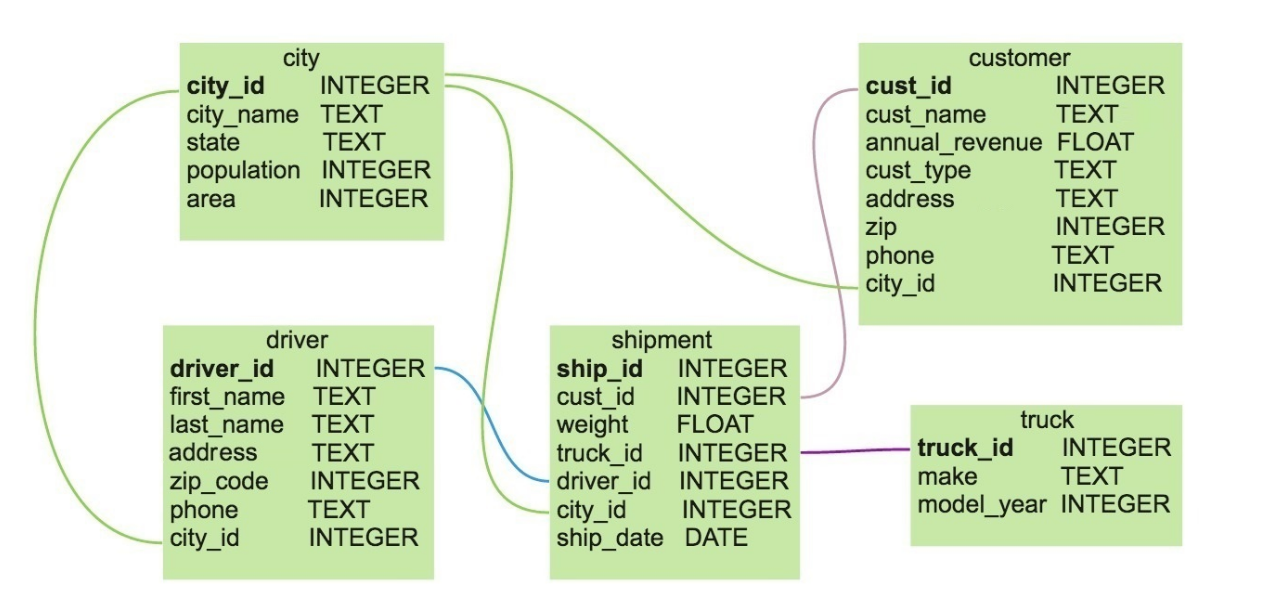

>Укажите название города с максимальным весом единичной доставки
```sql
select
    c.city_name,
    max(s.weight)
from
    sql.city c
    join sql.shipment s on s.city_id = c.city_id
group by c.city_name
order by max(s.weight) desc
limit 1

>Сколько различных производителей грузовиков перечислено в таблице truck?
```sql
select distinct
make
from sql.truck

>Как зовут водителя (first_name), который совершил наибольшее количество доставок одному клиенту?
```sql
select
    d.first_name,
    count(s.cust_id)
from
    sql.driver d
    join sql.shipment s on d.driver_id = s.driver_id
group by d.first_name
order by count(s.cust_id) desc
limit 1

> Укажите даты первой и последней по времени доставок в таблице shipment.
Ответ введите в формате ДД.ММ.ГГГГ.

```sql
select
ship_date
from sql.shipment
order by ship_date

>Укажите имя клиента, получившего наибольшее количество доставок за 2017 год.
```sql
select
    c.cust_name,
    count(s.ship_id)
from 
    sql.customer c
    join sql.shipment s on c.cust_id = s.cust_id
where s.ship_date between '01-01-2017' and '12-31-2017'
Group by cust_name 
order by 2 desc ,1
limit 1

>Формат даты можно определить, выведя текущую дату: 
```sql
SELECT CURRENT_DATE

>Через EXTRACT (работает с датой и временем)  позволяет вытащить из даты число, месяц и год
```sql
WHERE EXTRACT(YEAR FROM s.ship_date) = 2017

---

## <center> Принцип и условия работы Union

```sql
SELECT book_name object_name, 'книга' object_descritption /*выбираем столбец с названием book_name, задаём алиас для столбца object_name, задаём во второй колонке объект ‘книга’ с алиасом для столбца object_descritption*/
FROM public.books /*из схемы public и таблицы books*/
UNION ALL /*оператор присоединения*/
SELECT movie_title, 'фильм' /*выбираем столбец movie_title, сами задаём во второй колонке объект ‘фильм’*/
FROM sql.kinopoisk /*из схемы sql и таблицы kinopoisk*/

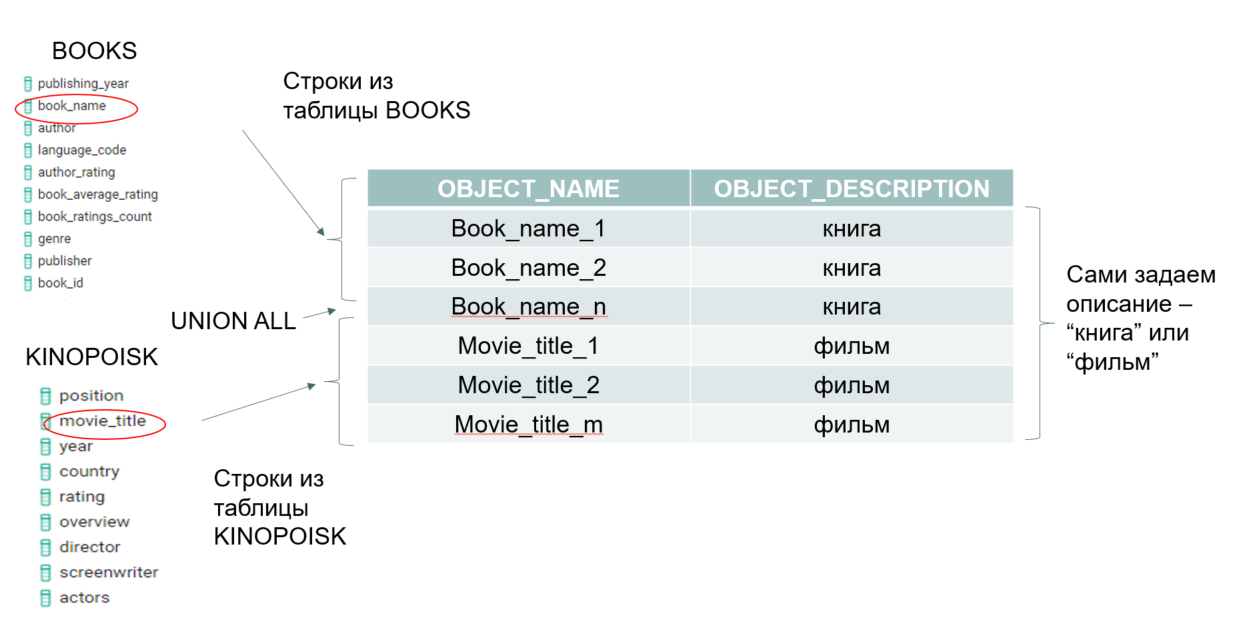

В запросе мы использовали оператор UNION ALL — он присоединяет любой результат запроса к другому «снизу» при условии, что у них одинаковая структура, а именно:
* одинаковый тип данных;
* одинаковое количество столбцов;
* одинаковый порядок столбцов согласно типу данных.

 <center> Виды UNION



Оператор присоединения существует в двух вариантах:
* UNION выводит только уникальные записи;
* UNION ALL присоединяет все строки последующих таблиц к предыдущим, без ограничений по уникальности.

>Важно! UNION оставляет только уникальные значения, а потому требует дополнительных вычислительных мощностей и памяти (в данном случае можно провести аналогию с DISTINCT). Поэтому если вы уверены в отсутствии дубликатов в данных или они вам не важны, предпочтительнее использовать UNION ALL.

<center> Синтаксис

```sql
SELECT         n columns
FROM 
         table_1
UNION ALL
SELECT 
         n columns
FROM 
         table_2
...
UNION ALL
SELECT 
         n columns
FROM 
         table_n

>Важно! Названия итоговых колонок в выводе будут такие же, как в первом блоке SELECT, даже если они отличаются в других блоках подзапросов.

```sql
SELECT
         c.city_id object_name,  'id города' object_type /*выбираем колонку city_id и задаём ей алиас object_name, сами задаём объект 'id города' и название столбца object_type*/
FROM 
         sql.city c /*из схемы sql и таблицы city, задаём алиас таблице — с*/
UNION ALL /*оператор присоединения*/
SELECT
         d.driver_id other_name,  'id водителя' other_type /*выбираем колонку driver_id и задаём ей алиас other_name, сами задаём объект 'id водителя' и название столбца other_type*/
FROM 
         sql.driver d  /*из схемы sql и таблицы driver, задаём алиас таблице — d*/
UNION ALL /*оператор присоединения*/
SELECT
         s.ship_id,  'id доставки' /*выбираем колонку ship_id, сами задаём объект 'id доставки'*/
FROM 
         sql.shipment s /*из схемы sql и таблицы shipment, задаём алиас таблице — s*/
UNION ALL /*оператор присоединения*/
SELECT
         c.cust_id,  'id клиента' /*выбираем колонку cust_id, сами задаём объект 'id клиента'*/
FROM 
         sql.customer c /*из схемы sql и таблицы customer, задаём алиас таблице — c*/
UNION ALL /*оператор присоединения*/
SELECT
         t.truck_id,  'id грузовика' /*выбираем колонку truck_id, сами задаём объект 'id грузовика'*/
FROM 
         sql.truck t /*из схемы sql и таблицы truck, задаём алиас таблице — t*/
ORDER BY 1 /*сортировка по первому столбцу*/

>Обратите внимание! Несмотря на исходные названия колонок other_name и other_type во втором подзапросе, в выводе мы получим названия, которые дали в первом блоке: object_name и object_type.

>Другая особенность — в применении сортировки ORDER BY: она всегда будет относиться к итоговому результату всего запроса с UNION ALL.

>В случаях, когда необходимо применить команду ORDER BY или LIMIT не к итоговому результату, а к каждой части запроса, можно обернуть подзапросы в скобки.

```sql
(SELECT book_name object_name, 'книга' object_descritption 
FROM public.books
ORDER BY 1
LIMIT 1)
UNION ALL
(SELECT movie_title, 'фильм' 
FROM sql.kinopoisk
ORDER BY 1
LIMIT 1)

>Напишите запрос, который создает уникальный алфавитный справочник всех городов, штатов, имён водителей и производителей грузовиков. Результатом запроса должны быть два столбца: название и тип объекта (city, state, driver, truck). Отсортируйте список по названию объекта, а затем — по типу.
```sql
select 
    c.city_name object_name,  'city' object_type
from sql.city c

union
select 
    c.state ,  'state' 
from sql.city c

union
select 
    d.first_name ,  'driver' 
from sql.driver d

union
select 
    t.make ,  'truck' 
from sql.truck t

order by 1, 2

>Напишите запрос, который соберёт имена всех упомянутых городов и штатов из таблицы city. Результатом запроса должен быть один столбец object_name, отсортированный в алфавитном порядке.
```sql
select
    c.city_name object_name
from sql.city c

union all

select c.state
from sql.city c

order by 1

---
UNION может быть использован только в случае полного соответствия столбцов и их типов в объединяемых запросах.

Если мы всё же хотим выполнить поставленную задачу, придётся привести оба столбца к одному типу данных. Не каждый текст может быть приведён к числу, зато каждое число может быть представлено в текстовом формате.

Забегая вперёд, скажем пару слов о типизации столбцов. Для типизации в Postgres составляется запрос по модели ```column_name::column_type```.

Таким образом, чтобы перевести city_id в текст, нам потребуется написать ```city_id::text```

>Важно! Любой тип данных может быть приведён к текстовому формату — эту возможность целесообразно использовать для соединения разнородных сущностей. Главное — помнить, что сортировка текста отличается от сортировки чисел и дат.

```sql
SELECT 
         c.city_id::text /*выбираем столбец city_id, переводим city_id из числового в текстовый формат*/
FROM
         sql.city c /*из схемы sql  и таблицы city, задаём таблице алиас с*/

UNION ALL /*оператор присоединения*/

SELECT 
         cc.city_name /*выбираем столбец city_name*/
FROM
         sql.city cc /*из схемы sql и таблицы city, задаём таблице алиас сс*/

>Напишите запрос, который объединит в себе все почтовые индексы водителей и их телефоны в единый столбец-справочник contact. Также добавьте столбец с именем водителя first_name и столбец contact_type с типом контакта (phone или zip в зависимости от типа). Отсортируйте список по столбцу с контактными данными в порядке возрастания, а затем — по имени водителя.
```sql
SELECT
    d.zip_code::text contact,
    d.first_name first_name,
    'zip' contact_type
FROM
    sql.driver d
UNION
SELECT
    dd.phone contact,
    dd.first_name first_name,
    'phone' contact_type
FROM
    sql.driver dd
ORDER BY 1,2

>Попробуем вывести обобщённые данные о населении по всем городам, с детализацией до конкретного города.
```sql
SELECT
         c.city_name,
         c.population
FROM
         sql.city c
UNION ALL
SELECT
         'total',
         SUM(c.population)
FROM
         sql.city c
ORDER BY 2 DESC

>Напишите запрос, который выводит общее число доставок total_shipments, а также количество доставок в каждый день. Необходимые столбцы: date_period, cnt_shipment. Не забывайте о единой типизации. Упорядочите по убыванию столбца date_period.
```sql
select
    s.ship_date::text date_period,
    count(s.ship_id)  cnt_shipment
from
    sql.shipment s
group by s.ship_date
union all

select 
    'total_shipments',
    count(s.ship_id)
from sql.shipment s

ORDER BY 1 DESC

>Например, с помощью UNION можно отобразить, у кого из водителей заполнен столбец с номером телефона.
```sql
SELECT
         d.first_name,
         d.last_name,
         'телефон заполнен' phone_info
FROM
         sql.driver d
WHERE d.phone IS NOT NULL

UNION

SELECT
         d.first_name,
         d.last_name,
         'телефон не заполнен' phone_info
FROM
         sql.driver d
WHERE d.phone IS NULL

```where```  фильтрует каждую таблицу отдельно

>Напишите запрос, который выведет все города и штаты, в которых они расположены, а также информацию о том, была ли осуществлена доставка в этот город:
* если в город была осуществлена доставка, то выводим 'доставка осуществлялась';
* если нет — выводим 'доставка не осуществлялась'.
* Столбцы к выводу: city_name, state, shipping_status. Отсортируйте в алфавитном порядке по городу, а затем — по штату.

```sql
select
    c.city_name,
    c.state,
    'доставка осуществлялась' shipping_status
from
    sql.city c
    left join sql.shipment s on c.city_id = s.city_id
where s.ship_id is not null

union

select
    c.city_name,
    c.state,
    'доставка не осуществлялась' shipping_status
from
    sql.city c
    left join sql.shipment s on c.city_id = s.city_id
where s.ship_id is null

order by 1,2


>Напишите запрос, который выводит два столбца: city_name и shippings_fake. Выведите города, куда совершались доставки. Пусть первый столбец содержит название города, а второй формируется так:
* если в городе было более десяти доставок, вывести количество доставок в этот город как есть;
* иначе — вывести количество доставок, увеличенное на пять.

Отсортируйте по убыванию получившегося «нечестного» количества доставок, а затем — по имени в алфавитном порядке.

```sql
select
    c.city_name,
    count(s.ship_id) shippings_fake
from
    sql.city c
    left join sql.shipment s on c.city_id = s.city_id
where s.ship_id is not null    
group by c.city_name
having count(s.ship_id) > 10

union 

select
    c.city_name,
    count(s.ship_id) +5 shippings_fake
from
    sql.city c
    left join sql.shipment s on c.city_id = s.city_id
where s.ship_id is not null 
group by c.city_name
having count(s.ship_id) <= 10

order by 2 desc, 1

## UNION и ручная генерация

>Составим запрос, который позволит вывести первые три буквы алфавита и их порядковые номера
```sql
SELECT 
         'a' letter,'1' ordinal_position
UNION 
SELECT 
         'b','2'
UNION 
SELECT
         'c','3'

>Напишите запрос, который выберет наибольшее из числовых значений:
* 1000000;
* 541;
* -500;
* 100.

Столбец с результатом назовите result.

```sql
select
1000000 result

union
select 
541

union
select
-500

union
select
100

order by 1 desc
limit 1

>Помним, что сортировка для числовых и строковых типов данных отличается. Построив запрос по аналогии с примером, приведите значения к текстовому типу данных, сравните и выберите наибольшее из них:
* 1000000;
* 541;
* -500;
* 100.

Столбец с ответом назовите mycol
```sql
select
'1000000' mycol

union
select 
'541'

union
select
'-500'

union
select
'100'

order by 1 desc
limit 1

>Построив запрос по аналогии с примером, найдите самое большое значение из перечисленных операторов:
* + ;
* - ;
* = ;
* / .

Столбец с ответом назовите result.
```sql
select
'+' result

union
select 
'-'

union
select
'='

union
select
'/'

order by 1 desc
limit 1

## <center> EXCEPT
### Исключаем повторяющиеся данные

>Предположим, нам нужно узнать, в какие города осуществлялась доставка, за исключением тех, в которых проживают водители.
```sql
SELECT
         c.city_name
FROM
         sql.shipment s
JOIN sql.city c ON s.city_id = c.city_id
EXCEPT
SELECT
         cc.city_name
FROM
         sql.driver d 
JOIN sql.city cc ON d.city_id=cc.city_id
ORDER BY 1

Чтобы лучше понять данный тип присоединения, предлагаем ознакомиться с диаграммой Венна — математическим инструментом, представляющим возможные логические связи между соединёнными наборами данных.

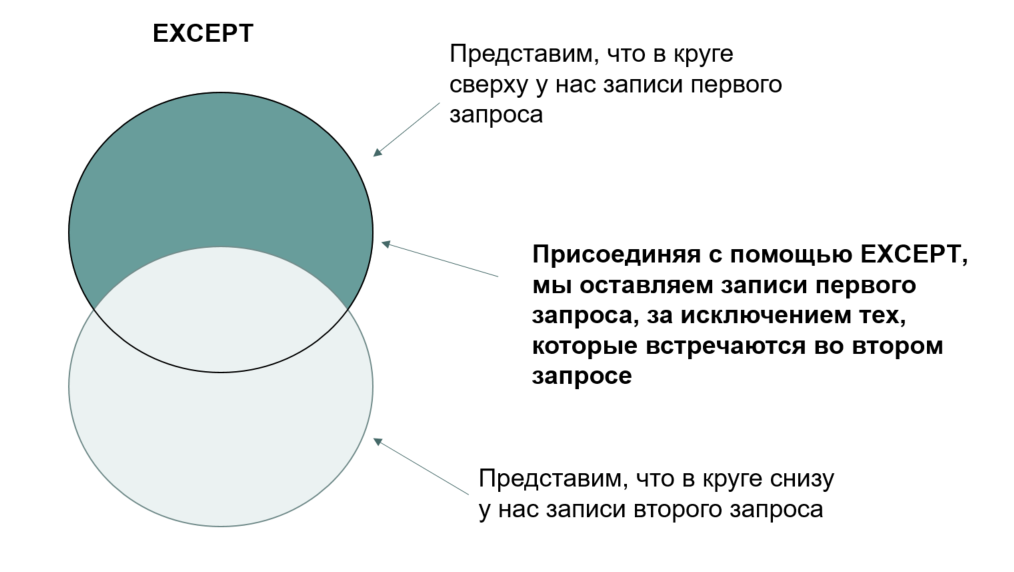

Синтаксические правила для оператора EXCEPT такие же, как и для UNION:
* одинаковый тип данных;
* одинаковое количество столбцов;
* одинаковый порядок столбцов согласно типу данных.

Синтаксис выглядит следующим образом:
```sql
SELECT 
         n columns
FROM 
         table_1
EXCEPT
SELECT 
         n columns
FROM 
         table_2

>Мы уже знаем, как решить такую задачу с использованием LEFT JOIN. Вариант с EXCEPT будет полезен в тех случаях, когда у вас много столбцов и вам не хочется прописывать их равенство в условии для JOIN.

>Выведите список zip-кодов, которые есть в таблице sql.driver, но отсутствуют в таблице sql.customer. Отсортируйте по возрастанию, столбец к выводу — zip. В поле ниже введите запрос, с помощью которого вы решили эту задачу.
```sql
select
    d.zip_code zip
from
    sql.driver d

except

select
    c.zip
from
    sql.customer c

order by 1

## <center> INTERSECT

### Выбираем общие данные

```sql
SELECT          c.city_name object_name
FROM          sql.city c
INTERSECT
SELECT 
         cc.state
FROM          sql.city cc
ORDER BY 1

Чтобы лучше понять, как работает этот оператор, вновь обратимся к диаграмме Венна: INTERSECT оставляет из результатов первого запроса все строки, которые совпали с результатом выполнения второго запроса.

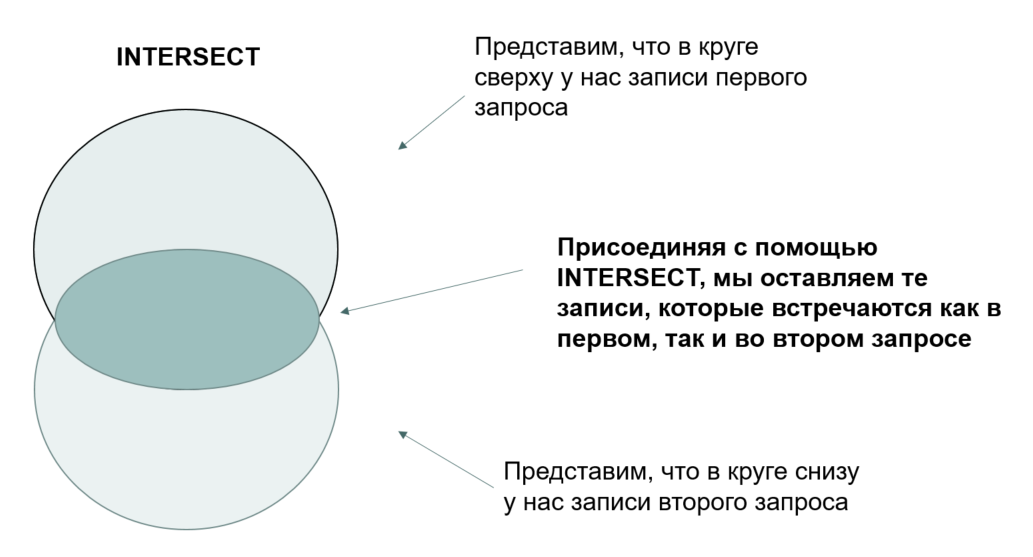

Синтаксис запроса с оператором INTERSECT выглядит следующим образом:
```sql
SELECT 
         n columns
FROM 
         table_1
INTERSECT
SELECT 
         n columns
FROM 
         table_2

>Как EXCEPT, так и INTERSECT убирают дубликаты, если они имеются.

>Напишите запрос, который выведет список id городов, в которых есть и клиенты, и доставки, и водители.
```sql
select
    city_id
from
    sql.city

intersect

select
    city_id
from
    sql.customer

intersect

select
    city_id
from
    sql.shipment

intersect

select
    city_id
from
    sql.driver

>Выведите zip-код, который есть как в таблице с клиентами, так и в таблице с водителями.
```sql
select
    c.zip
from sql.customer c

intersect

select
    d.zip_code
from sql.driver d

---

```sql
SELECT          N columns
FROM          table_1
UNION / UNION ALL / EXCEPT / INTERSECT 
SELECT          N columns
FROM          table_2

>Выведите города с максимальным и минимальным весом единичной доставки. Столбцы к выводу — city_name, weight.
```sql
(select 
    city_name,
    max(s.weight) weight
from 
    sql.city c
    join sql.shipment s on c.city_id = s.city_id
group by c.city_name
order by 2 desc
limit 1)

union

(select
    c.city_name,
    min(s.weight) weight
    
from 
    sql.city c
    join sql.shipment s on c.city_id = s.city_id
group by c.city_name
order by 2 
limit 1)

>Выведите идентификационные номера клиентов (cust_id), которые совпадают с идентификационными номерами доставок (ship_id). Столбец к выводу — mutual_id. Отсортируйте по возрастанию.
```sql
select
c.cust_id mutual_id,
from
    sql.customer c 
join sql.shipment s on c.cust_id = s.cust_id

intersect

select
s.ship_id,
from
    sql.customer c 
join sql.shipment s on c.cust_id = s.cust_id

order by 1

>Создайте справочник, содержащий уникальные имена клиентов, которые являются производителями (cust_type='manufacturer'), и производителей грузовиков, а также описание объекта — 'КЛИЕНТ' или 'ГРУЗОВИК'. Столбцы к выводу — object_name, object_description. Отсортируйте по названию в алфавитном порядке.
```sql
select
c.cust_name object_name,
'КЛИЕНТ' object_description
from
    sql.customer c
where cust_type='manufacturer'

union

select
t.make,
'ГРУЗОВИК'
from sql.truck t

order by 1